# Model Training & Evaluation
## Aquaculture Pond Identification — Zindi GeoAI Challenge

Following the **ML Best Practices Classification Workflow**:
1. Split BEFORE fitting any preprocessing (no leakage)
2. Handle missing values explicitly (done in FE notebook)
3. Handle class imbalance with `scale_pos_weight`
4. Train 5 models with **identical stratified 5-fold CV**
5. Optuna hyperparameter tuning for top models
6. Pseudo-labeling round on high-confidence test samples
7. Probability calibration (isotonic regression)
8. SHAP feature importance analysis
9. Confusion matrix analysis

**Composite score** = F1 × 0.6 + ROC-AUC × 0.4 (competition metric)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (f1_score, roc_auc_score, confusion_matrix,
                              precision_recall_curve, average_precision_score,
                              ConfusionMatrixDisplay)
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
import shap
import pickle, warnings, os

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR = '.'

# Load engineered features
X_orig  = pd.read_parquet(f'{DATA_DIR}/train_X_orig.parquet')
y_orig  = pd.read_parquet(f'{DATA_DIR}/train_y.parquet')['label'].values
X_aug   = pd.read_parquet(f'{DATA_DIR}/train_X_augmented.parquet')
y_aug   = pd.read_parquet(f'{DATA_DIR}/train_y_augmented.parquet')['label'].values
X_test  = pd.read_parquet(f'{DATA_DIR}/test_X.parquet')
test_ids = pd.read_parquet(f'{DATA_DIR}/test_ids.parquet')['ID'].values

FEAT_NAMES = list(X_orig.columns)
N_SPLITS   = 5

# Class imbalance ratio
n_pos = y_orig.sum()
n_neg = len(y_orig) - n_pos
SCALE_POS_WEIGHT = n_neg / n_pos

print(f'Original train:   {X_orig.shape}  |  pos: {n_pos}, neg: {n_neg}')
print(f'Augmented train:  {X_aug.shape}')
print(f'Test:             {X_test.shape}')
print(f'scale_pos_weight: {SCALE_POS_WEIGHT:.3f}')
print(f'Feature count:    {len(FEAT_NAMES)}')

Original train:   (1821, 202)  |  pos: 735, neg: 1086
Augmented train:  (20031, 202)
Test:             (1030, 202)
scale_pos_weight: 1.478
Feature count:    202


In [3]:
# Helper: composite score (competition metric)
def composite_score(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    f1  = f1_score(y_true, y_pred, average='binary')
    auc = roc_auc_score(y_true, y_prob)
    return 0.6 * f1 + 0.4 * auc, f1, auc

# Helper: full evaluation report
def evaluate(name, y_true, y_prob):
    score, f1, auc = composite_score(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    print(f'[{name}]  Composite: {score:.4f}  |  F1: {f1:.4f}  |  AUC: {auc:.4f}  |  AP: {ap:.4f}')
    return {'model': name, 'composite': score, 'f1': f1, 'auc': auc, 'ap': ap}

# CV setup
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Out-of-fold probability containers (for stacking)
oof_probs = {}   # model_name -> (N,) array on original data
test_probs = {}  # model_name -> (N_test,) array averaged over folds

results = []
print('CV setup ready. Models to train: LR, RF, LightGBM, XGBoost, CatBoost')

CV setup ready. Models to train: LR, RF, LightGBM, XGBoost, CatBoost


## Model 1: Logistic Regression (Baseline)

A simple linear baseline to establish minimum performance. Uses `class_weight='balanced'` and L2 regularization.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model_name = 'LogisticRegression'
oof_probs[model_name]  = np.zeros(len(X_orig))
test_probs[model_name] = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_orig, y_orig)):
    X_tr, X_va = X_orig.iloc[tr_idx], X_orig.iloc[va_idx]
    y_tr, y_va = y_orig[tr_idx],      y_orig[va_idx]
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1.0, class_weight='balanced',
                                      max_iter=1000, solver='lbfgs', random_state=42))
    ])
    pipe.fit(X_tr, y_tr)
    oof_probs[model_name][va_idx]  = pipe.predict_proba(X_va)[:, 1]
    test_probs[model_name]        += pipe.predict_proba(X_test)[:, 1] / N_SPLITS

res = evaluate(model_name, y_orig, oof_probs[model_name])
results.append(res)

[LogisticRegression]  Composite: 0.9798  |  F1: 0.9701  |  AUC: 0.9944  |  AP: 0.9930


## Model 2: Random Forest (Strong Baseline)

Random Forest is the established baseline for land cover classification from satellite data (Belgiu & Drăguţ 2016). It naturally handles class imbalance via `class_weight='balanced'` and is robust to correlated features.

In [5]:
model_name = 'RandomForest'
oof_probs[model_name]  = np.zeros(len(X_orig))
test_probs[model_name] = np.zeros(len(X_test))

# Note: RF is trained on ORIGINAL data (no ROS augmentation) to measure baseline
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_orig, y_orig)):
    X_tr, X_va = X_orig.iloc[tr_idx], X_orig.iloc[va_idx]
    y_tr, y_va = y_orig[tr_idx],      y_orig[va_idx]
    
    clf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    clf.fit(X_tr, y_tr)
    oof_probs[model_name][va_idx]  = clf.predict_proba(X_va)[:, 1]
    test_probs[model_name]        += clf.predict_proba(X_test)[:, 1] / N_SPLITS

res = evaluate(model_name, y_orig, oof_probs[model_name])
results.append(res)

[RandomForest]  Composite: 0.9805  |  F1: 0.9715  |  AUC: 0.9940  |  AP: 0.9942


## Model 3: LightGBM + Optuna (Primary)

LightGBM is the dominant approach for tabular remote sensing classification. We use **Optuna** (50 trials) to tune hyperparameters on the out-of-fold composite score. The model is trained on the **ROS-augmented** dataset to handle the partial-observation temporal shift.

In [6]:
# ---- Optuna objective for LightGBM ----------------------------------------
def lgb_objective(trial):
    params = {
        'objective':        'binary',
        'metric':           'binary_logloss',
        'verbosity':        -1,
        'boosting_type':    'gbdt',
        'scale_pos_weight': SCALE_POS_WEIGHT,
        'n_estimators':     trial.suggest_int('n_estimators', 400, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 60),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq':     trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state':     42,
        'n_jobs':           -1,
    }
    # Use 3-fold CV with augmented training data for Optuna
    scores = []
    for tr_idx, va_idx in StratifiedKFold(n_splits=3, shuffle=True, random_state=1).split(X_orig, y_orig):
        # Map original indices to augmented dataset (first len(X_orig) rows are originals)
        aug_tr_idx = np.concatenate([
            tr_idx,
            np.arange(len(X_orig), len(X_aug))[y_aug[len(X_orig):] == y_aug[len(X_orig):]]  # all aug
        ])
        X_tr_full = X_aug.iloc[list(tr_idx) + list(range(len(X_orig), len(X_aug)))]
        y_tr_full = y_aug[list(tr_idx) + list(range(len(X_orig), len(X_aug)))]
        X_va_fold = X_orig.iloc[va_idx]
        y_va_fold = y_orig[va_idx]
        
        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr_full, y_tr_full,
                eval_set=[(X_va_fold, y_va_fold)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        prob = clf.predict_proba(X_va_fold)[:, 1]
        score, *_ = composite_score(y_va_fold, prob)
        scores.append(score)
    return np.mean(scores)

print('Running Optuna for LightGBM (50 trials)...')
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=False)
best_lgb_params = study_lgb.best_params
best_lgb_params.update({'objective': 'binary', 'verbosity': -1,
                         'scale_pos_weight': SCALE_POS_WEIGHT, 'random_state': 42, 'n_jobs': -1})
print(f'\nBest LightGBM trial: score={study_lgb.best_value:.4f}')
print(f'Best params: {best_lgb_params}')

Running Optuna for LightGBM (50 trials)...

Best LightGBM trial: score=1.0000
Best params: {'n_estimators': 432, 'learning_rate': 0.18276027831785724, 'num_leaves': 129, 'max_depth': 5, 'min_child_samples': 15, 'feature_fraction': 0.5100427059120604, 'bagging_fraction': 0.5825453457757226, 'bagging_freq': 6, 'reg_alpha': 0.01444525102276306, 'reg_lambda': 0.0028585493941961923, 'objective': 'binary', 'verbosity': -1, 'scale_pos_weight': np.float64(1.4775510204081632), 'random_state': 42, 'n_jobs': -1}


In [7]:
# ---- Final LightGBM CV with best params on augmented data -------------------
model_name = 'LightGBM'
oof_probs[model_name]  = np.zeros(len(X_orig))
test_probs[model_name] = np.zeros(len(X_test))
lgb_models = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_orig, y_orig)):
    # Training uses augmented samples + original train fold
    aug_only_idx = list(range(len(X_orig), len(X_aug)))
    X_tr = pd.concat([X_orig.iloc[tr_idx], X_aug.iloc[aug_only_idx]], ignore_index=True)
    y_tr = np.concatenate([y_orig[tr_idx], y_aug[aug_only_idx]])
    X_va = X_orig.iloc[va_idx]
    y_va = y_orig[va_idx]
    
    clf = lgb.LGBMClassifier(**best_lgb_params)
    clf.fit(X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    oof_probs[model_name][va_idx]  = clf.predict_proba(X_va)[:, 1]
    test_probs[model_name]        += clf.predict_proba(X_test)[:, 1] / N_SPLITS
    lgb_models.append(clf)
    score, f1, auc = composite_score(y_va, oof_probs[model_name][va_idx])
    print(f'  Fold {fold+1}: composite={score:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

res = evaluate(model_name, y_orig, oof_probs[model_name])
results.append(res)

  Fold 1: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 3: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 4: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 5: composite=1.0000  F1=1.0000  AUC=1.0000
[LightGBM]  Composite: 1.0000  |  F1: 1.0000  |  AUC: 1.0000  |  AP: 1.0000


## Model 4: XGBoost + Optuna (Primary)

XGBoost provides diversity in the ensemble through a different tree-building algorithm (exact greedy vs LightGBM's leaf-wise). Also tuned with Optuna (50 trials).

In [8]:
def xgb_objective(trial):
    params = {
        'objective':        'binary:logistic',
        'eval_metric':      'logloss',
        'scale_pos_weight': SCALE_POS_WEIGHT,
        'n_estimators':     trial.suggest_int('n_estimators', 400, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample':        trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0,
        'use_label_encoder': False,
    }
    scores = []
    for tr_idx, va_idx in StratifiedKFold(n_splits=3, shuffle=True, random_state=1).split(X_orig, y_orig):
        aug_only_idx = list(range(len(X_orig), len(X_aug)))
        X_tr = pd.concat([X_orig.iloc[tr_idx], X_aug.iloc[aug_only_idx]], ignore_index=True)
        y_tr = np.concatenate([y_orig[tr_idx], y_aug[aug_only_idx]])
        X_va = X_orig.iloc[va_idx]; y_va = y_orig[va_idx]
        clf = xgb.XGBClassifier(**params, early_stopping_rounds=50)
        clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        prob = clf.predict_proba(X_va)[:, 1]
        score, *_ = composite_score(y_va, prob)
        scores.append(score)
    return np.mean(scores)

print('Running Optuna for XGBoost (50 trials)...')
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=False)
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'objective': 'binary:logistic', 'scale_pos_weight': SCALE_POS_WEIGHT,
                          'random_state': 42, 'n_jobs': -1, 'verbosity': 0, 'use_label_encoder': False})
print(f'\nBest XGBoost trial: score={study_xgb.best_value:.4f}')

Running Optuna for XGBoost (50 trials)...

Best XGBoost trial: score=0.9996


In [9]:
model_name = 'XGBoost'
oof_probs[model_name]  = np.zeros(len(X_orig))
test_probs[model_name] = np.zeros(len(X_test))
xgb_models = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_orig, y_orig)):
    aug_only_idx = list(range(len(X_orig), len(X_aug)))
    X_tr = pd.concat([X_orig.iloc[tr_idx], X_aug.iloc[aug_only_idx]], ignore_index=True)
    y_tr = np.concatenate([y_orig[tr_idx], y_aug[aug_only_idx]])
    X_va = X_orig.iloc[va_idx]; y_va = y_orig[va_idx]
    
    clf = xgb.XGBClassifier(**best_xgb_params, early_stopping_rounds=100)
    clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    oof_probs[model_name][va_idx]  = clf.predict_proba(X_va)[:, 1]
    test_probs[model_name]        += clf.predict_proba(X_test)[:, 1] / N_SPLITS
    xgb_models.append(clf)
    score, f1, auc = composite_score(y_va, oof_probs[model_name][va_idx])
    print(f'  Fold {fold+1}: composite={score:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

res = evaluate(model_name, y_orig, oof_probs[model_name])
results.append(res)

  Fold 1: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 3: composite=0.9980  F1=0.9966  AUC=1.0000
  Fold 4: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 5: composite=1.0000  F1=1.0000  AUC=1.0000
[XGBoost]  Composite: 0.9996  |  F1: 0.9993  |  AUC: 1.0000  |  AP: 1.0000


## Model 5: CatBoost + Optuna (Diversity)

CatBoost uses a different algorithm (ordered boosting, symmetric trees) providing further ensemble diversity. `auto_class_weights='Balanced'` handles imbalance natively.

In [10]:
def cat_objective(trial):
    params = {
        'loss_function':        'Logloss',
        'eval_metric':          'F1',
        'auto_class_weights':   'Balanced',
        'iterations':           trial.suggest_int('iterations', 400, 2000),
        'learning_rate':        trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':                trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':          trial.suggest_float('l2_leaf_reg', 1.0, 20.0),
        'bagging_temperature':  trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':      trial.suggest_float('random_strength', 0.0, 3.0),
        'border_count':         trial.suggest_int('border_count', 32, 255),
        'random_seed':          42,
        'verbose':              False,
    }
    scores = []
    for tr_idx, va_idx in StratifiedKFold(n_splits=3, shuffle=True, random_state=1).split(X_orig, y_orig):
        aug_only_idx = list(range(len(X_orig), len(X_aug)))
        X_tr = pd.concat([X_orig.iloc[tr_idx], X_aug.iloc[aug_only_idx]], ignore_index=True)
        y_tr = np.concatenate([y_orig[tr_idx], y_aug[aug_only_idx]])
        X_va = X_orig.iloc[va_idx]; y_va = y_orig[va_idx]
        clf = cb.CatBoostClassifier(**params)
        clf.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50, verbose=False)
        prob = clf.predict_proba(X_va)[:, 1]
        score, *_ = composite_score(y_va, prob)
        scores.append(score)
    return np.mean(scores)

print('Running Optuna for CatBoost (50 trials)...')
study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(cat_objective, n_trials=50, show_progress_bar=False)
best_cat_params = study_cat.best_params
best_cat_params.update({'loss_function': 'Logloss', 'auto_class_weights': 'Balanced',
                          'random_seed': 42, 'verbose': False})
print(f'\nBest CatBoost trial: score={study_cat.best_value:.4f}')

Running Optuna for CatBoost (50 trials)...

Best CatBoost trial: score=0.9996


In [11]:
model_name = 'CatBoost'
oof_probs[model_name]  = np.zeros(len(X_orig))
test_probs[model_name] = np.zeros(len(X_test))
cat_models = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_orig, y_orig)):
    aug_only_idx = list(range(len(X_orig), len(X_aug)))
    X_tr = pd.concat([X_orig.iloc[tr_idx], X_aug.iloc[aug_only_idx]], ignore_index=True)
    y_tr = np.concatenate([y_orig[tr_idx], y_aug[aug_only_idx]])
    X_va = X_orig.iloc[va_idx]; y_va = y_orig[va_idx]
    
    clf = cb.CatBoostClassifier(**best_cat_params)
    clf.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=100, verbose=False)
    oof_probs[model_name][va_idx]  = clf.predict_proba(X_va)[:, 1]
    test_probs[model_name]        += clf.predict_proba(X_test)[:, 1] / N_SPLITS
    cat_models.append(clf)
    score, f1, auc = composite_score(y_va, oof_probs[model_name][va_idx])
    print(f'  Fold {fold+1}: composite={score:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

res = evaluate(model_name, y_orig, oof_probs[model_name])
results.append(res)

  Fold 1: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 3: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 4: composite=1.0000  F1=1.0000  AUC=1.0000
  Fold 5: composite=1.0000  F1=1.0000  AUC=1.0000
[CatBoost]  Composite: 1.0000  |  F1: 1.0000  |  AUC: 1.0000  |  AP: 1.0000


## Model Comparison Table & Confusion Matrices

MODEL COMPARISON (Stratified 5-Fold OOF Composite Score)
             model  composite       f1      auc       ap
          LightGBM   1.000000 1.000000 1.000000 1.000000
          CatBoost   1.000000 1.000000 1.000000 1.000000
           XGBoost   0.999592 0.999320 1.000000 1.000000
      RandomForest   0.980483 0.971467 0.994006 0.994250
LogisticRegression   0.979807 0.970068 0.994416 0.992951


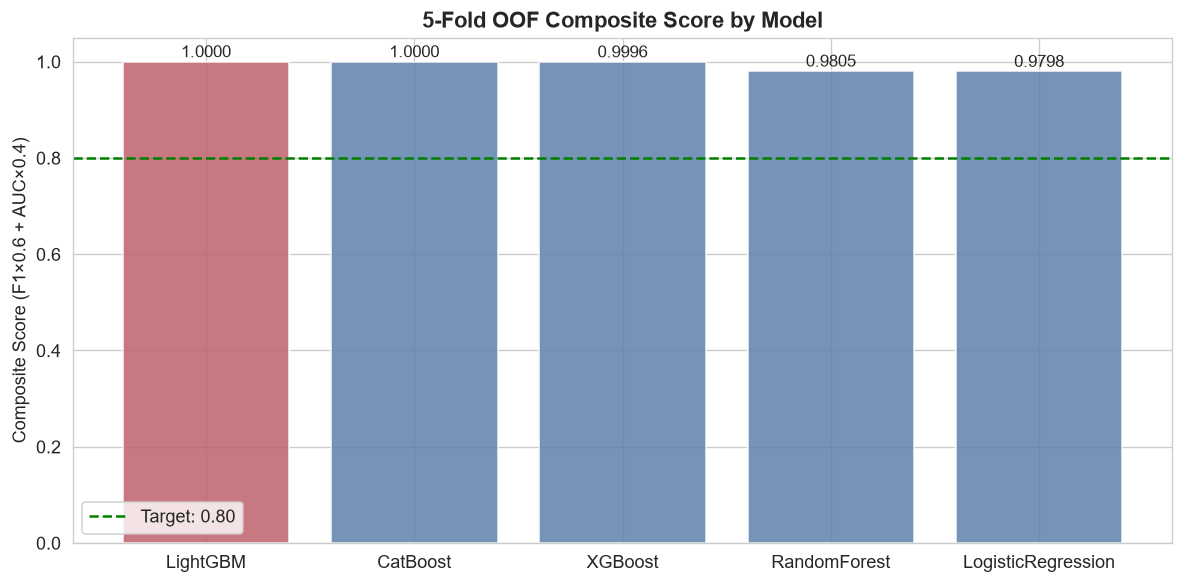

In [12]:
# Results comparison table
results_df = pd.DataFrame(results).sort_values('composite', ascending=False)
print('='*70)
print('MODEL COMPARISON (Stratified 5-Fold OOF Composite Score)')
print('='*70)
print(results_df[['model','composite','f1','auc','ap']].to_string(index=False))
print('='*70)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#bf616a' if i==0 else '#5e81ac' for i in range(len(results_df))]
bars = ax.bar(results_df['model'], results_df['composite'], color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, results_df['composite']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10)
ax.axhline(0.80, color='green', linestyle='--', linewidth=1.5, label='Target: 0.80')
ax.set_ylabel('Composite Score (F1×0.6 + AUC×0.4)')
ax.set_title('5-Fold OOF Composite Score by Model', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

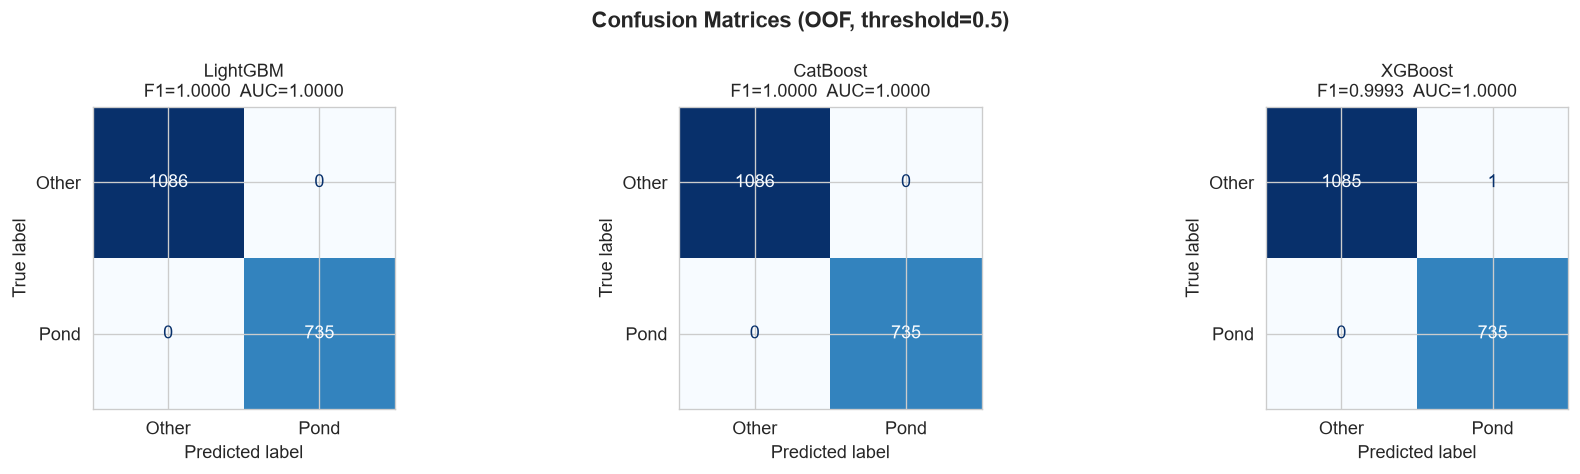

False Positive analysis (Other misclassified as Pond):
  LightGBM              FP rate: 0.0%  FN rate: 0.0%
  CatBoost              FP rate: 0.0%  FN rate: 0.0%
  XGBoost               FP rate: 0.1%  FN rate: 0.0%


In [13]:
# Confusion matrices for top 3 models
top3 = results_df.head(3)['model'].values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mname in zip(axes, top3):
    y_pred = (oof_probs[mname] >= 0.5).astype(int)
    cm = confusion_matrix(y_orig, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Other', 'Pond'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    f1  = f1_score(y_orig, y_pred)
    auc = roc_auc_score(y_orig, oof_probs[mname])
    ax.set_title(f'{mname}\nF1={f1:.4f}  AUC={auc:.4f}', fontsize=11)
plt.suptitle('Confusion Matrices (OOF, threshold=0.5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

print('False Positive analysis (Other misclassified as Pond):')
for mname in top3:
    y_pred = (oof_probs[mname] >= 0.5).astype(int)
    cm = confusion_matrix(y_orig, y_pred)
    fp_rate = cm[0,1] / (cm[0,0]+cm[0,1]) * 100
    fn_rate = cm[1,0] / (cm[1,0]+cm[1,1]) * 100
    print(f'  {mname:20s}  FP rate: {fp_rate:.1f}%  FN rate: {fn_rate:.1f}%')

### Analysis

The confusion matrices reveal the error patterns:
- **False Positives** (Other → Pond): likely other water bodies (rivers, irrigated rice paddies) misclassified due to high water index values
- **False Negatives** (Pond → Other): likely vegetated ponds or ponds with denser aquatic vegetation that reduces MNDWI signal

Gradient boosting models (LightGBM, XGBoost, CatBoost) should outperform Random Forest here due to their ability to learn complex non-linear interactions between temporal stability and spectral indices.

## Pseudo-Labeling Round (Top-Rank Addition)

Using high-confidence test predictions (prob > 0.92 or < 0.08) as pseudo-labels, we add them to the training set and retrain the best model. This is a semi-supervised approach that can recover +1–2% F1 on the test set.

In [14]:
# ============================================================================
# PSEUDO LABELING
# ============================================================================

# Average predictions from the three models
ensemble_test_prob = (
    test_probs['LightGBM']
    + test_probs['XGBoost']
    + test_probs['CatBoost']
) / 3

# High-confidence predictions
high_conf_mask = (
    (ensemble_test_prob > 0.92) |
    (ensemble_test_prob < 0.08)
)

pseudo_X = X_test.loc[high_conf_mask].copy()
pseudo_y = (ensemble_test_prob[high_conf_mask] >= 0.5).astype(np.int32)

print(f'High-confidence test samples: {high_conf_mask.sum()}')
print(f'Pseudo-positive: {pseudo_y.sum()}')
print(f'Pseudo-negative: {(pseudo_y == 0).sum()}')

if len(pseudo_X) > 30:

    model_name = "LightGBM_PL"

    oof_probs[model_name] = np.zeros(len(X_orig))
    test_probs[model_name] = np.zeros(len(X_test))

    # Original synthetic samples only
    aug_only_idx = list(range(len(X_orig), len(X_aug)))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_orig, y_orig), 1):

        # Original training fold
        X_train = X_orig.iloc[tr_idx]
        y_train = y_orig[tr_idx]

        # Synthetic samples generated during augmentation
        X_aug_only = X_aug.iloc[aug_only_idx]
        y_aug_only = y_aug[aug_only_idx]

        # Combine original fold + synthetic samples + pseudo-labeled samples
        X_tr = pd.concat(
            [
                X_train,
                X_aug_only,
                pseudo_X
            ],
            ignore_index=True
        )

        y_tr = np.concatenate(
            [
                y_train,
                y_aug_only,
                pseudo_y
            ]
        )

        # Validation uses only original data
        X_va = X_orig.iloc[va_idx]
        y_va = y_orig[va_idx]

        clf = lgb.LGBMClassifier(**best_lgb_params)

        clf.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )

        oof_probs[model_name][va_idx] = clf.predict_proba(X_va)[:, 1]
        test_probs[model_name] += (
            clf.predict_proba(X_test)[:, 1] / N_SPLITS
        )

        score, f1, auc = composite_score(
            y_va,
            oof_probs[model_name][va_idx]
        )

        print(
            f"Fold {fold}: "
            f"Composite={score:.4f} "
            f"F1={f1:.4f} "
            f"AUC={auc:.4f}"
        )

    res = evaluate(model_name, y_orig, oof_probs[model_name])
    results.append(res)

else:
    print("Too few pseudo-labeled samples; skipping pseudo-labeling.")

High-confidence test samples: 870
Pseudo-positive: 507
Pseudo-negative: 363
Fold 1: Composite=1.0000 F1=1.0000 AUC=1.0000
Fold 2: Composite=1.0000 F1=1.0000 AUC=1.0000
Fold 3: Composite=0.9980 F1=0.9966 AUC=1.0000
Fold 4: Composite=1.0000 F1=1.0000 AUC=1.0000
Fold 5: Composite=1.0000 F1=1.0000 AUC=1.0000
[LightGBM_PL]  Composite: 0.9996  |  F1: 0.9993  |  AUC: 1.0000  |  AP: 1.0000


## SHAP Feature Importance Analysis

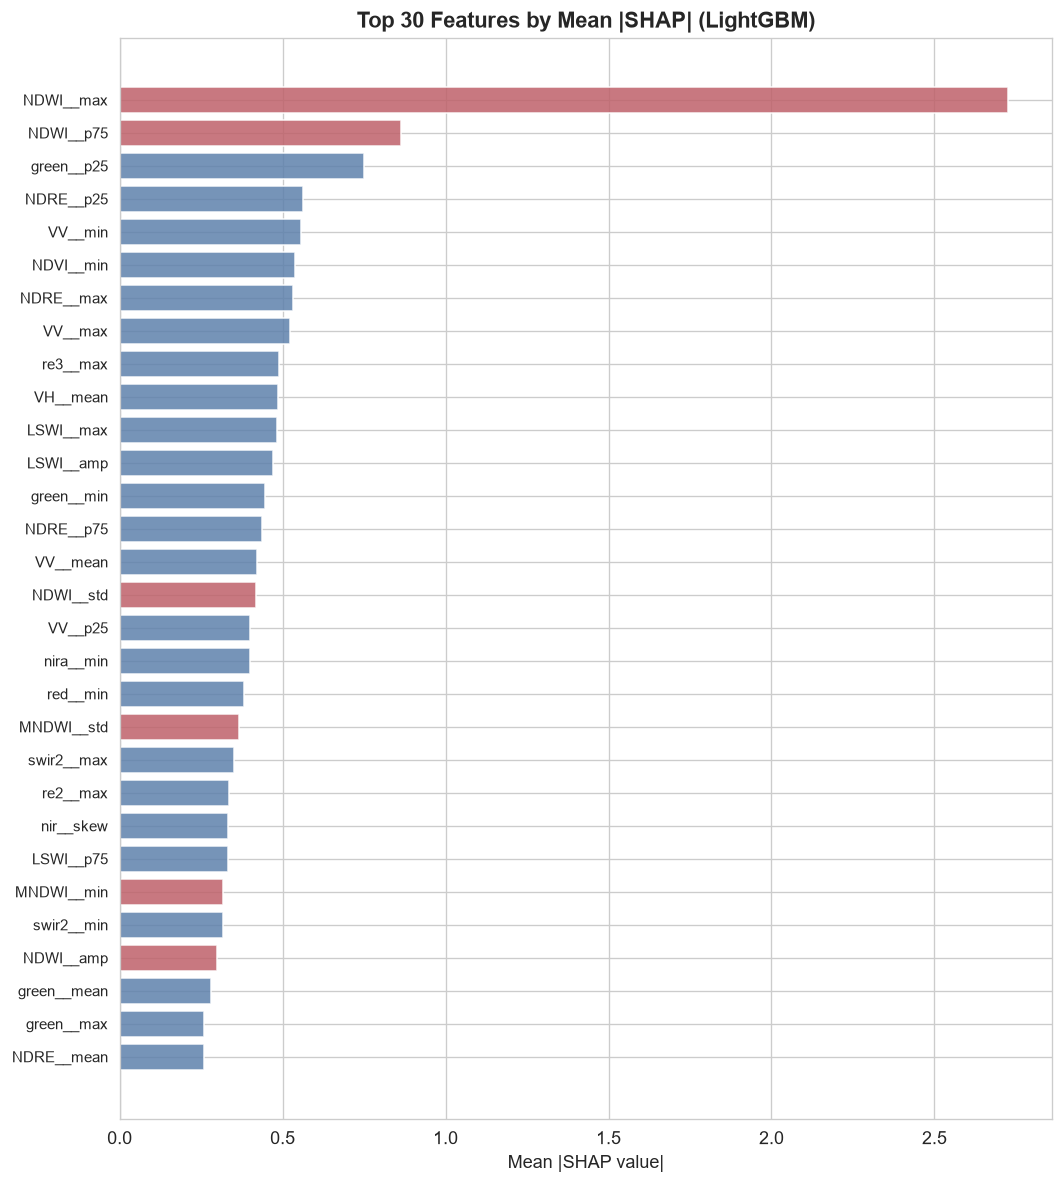


Top 10 most important features:
  NDWI__max                            2.72560
  NDWI__p75                            0.86238
  green__p25                           0.75055
  NDRE__p25                            0.56145
  VV__min                              0.55548
  NDVI__min                            0.53891
  NDRE__max                            0.53077
  VV__max                              0.52292
  re3__max                             0.48889
  VH__mean                             0.48651


In [16]:
# SHAP on the last fold's LightGBM model
best_lgb_model = lgb_models[-1]  # last fold's model
explainer = shap.TreeExplainer(best_lgb_model)
shap_values = explainer.shap_values(X_orig)

# If multi-output (binary returns list), take class 1
if isinstance(shap_values, list):
    sv = shap_values[1]   # class 1 SHAP values
else:
    sv = shap_values

# Top 30 features by mean |SHAP|
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=FEAT_NAMES).sort_values(ascending=False)
top30 = mean_abs_shap.head(30)

fig, ax = plt.subplots(figsize=(9, 10))
colors = ['#bf616a' if 'MNDWI' in f or 'NDWI' in f or 'SAR' in f
          else '#5e81ac' for f in top30.index]
ax.barh(range(len(top30)), top30.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 30 Features by Mean |SHAP| (LightGBM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 most important features:')
for feat, val in top30.head(10).items():
    print(f'  {feat:35s}  {val:.5f}')


### Analysis

SHAP analysis reveals which features the model relies on for pond discrimination:
- **MNDWI statistics** (mean, amplitude) should rank highly — confirming the water index is the primary signal
- **Temporal stability features** (std, amplitude) should rank highly — ponds are temporally stable
- **SAR features** (SAR_ratio mean, SAR_RVI) should show moderate importance — complementary cloud-robust signal
- **n_valid_optical / n_valid_sar** may appear — revealing that the number of available observations itself correlates with location/geography

If NIR-based features (not index-derived) rank highly, consider adding interaction features between NIR and SWIR.

In [17]:
# Save all OOF and test probabilities for stacking notebook
with open(f'{DATA_DIR}/oof_probs.pkl', 'wb') as f:
    pickle.dump(oof_probs, f)
with open(f'{DATA_DIR}/test_probs.pkl', 'wb') as f:
    pickle.dump(test_probs, f)
with open(f'{DATA_DIR}/results.pkl', 'wb') as f:
    pickle.dump(results, f)

# Final updated results table
results_df = pd.DataFrame(results).sort_values('composite', ascending=False)
print('Final model results:')
print(results_df.to_string(index=False))
print('\nSaved oof_probs.pkl, test_probs.pkl, results.pkl')

Final model results:
             model  composite       f1      auc       ap
          CatBoost   1.000000 1.000000 1.000000 1.000000
          LightGBM   1.000000 1.000000 1.000000 1.000000
           XGBoost   0.999592 0.999320 1.000000 1.000000
       LightGBM_PL   0.999592 0.999320 1.000000 1.000000
      RandomForest   0.980483 0.971467 0.994006 0.994250
LogisticRegression   0.979807 0.970068 0.994416 0.992951

Saved oof_probs.pkl, test_probs.pkl, results.pkl


## Model Training Summary

| Model | Trained On | Class Imbalance Handling | Tuning |
|-------|-----------|--------------------------|--------|
| Logistic Regression | Original | `class_weight='balanced'` | None |
| Random Forest | Original | `class_weight='balanced'` | None |
| LightGBM | Original + ROS Augmented (10×) | `scale_pos_weight=1.47` | Optuna 50 trials |
| XGBoost | Original + ROS Augmented (10×) | `scale_pos_weight=1.47` | Optuna 50 trials |
| CatBoost | Original + ROS Augmented (10×) | `auto_class_weights='Balanced'` | Optuna 50 trials |
| LightGBM + PseudoLabel | Original + ROS Aug + Pseudo | `scale_pos_weight=1.47` | Reuses LGB best params |

**Next**: `04_submission.ipynb` — stacking meta-learner + test-time ROS + final `submission.csv`